# Policy Gradient: REINFORCE with cart pole balancing

In [1]:
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import gymnasium as gym
import numpy as np

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [8]:
class PolicyNetwork(nn.Module):
    def __init__(self, state_size, action_size, hidden_size):
        super().__init__()
        self.layer1 = nn.Linear(state_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, hidden_size)
        self.output = nn.Linear(hidden_size, action_size)

    def forward(self, x):
        x = F.relu(self.layer1(x))
        x = F.relu(self.layer2(x))
        return F.log_softmax(self.output(x), dim=-1)  # log-probs, numerically stable

In [9]:
class CartPoleAgent:
    def __init__(self, state_size, action_size, hidden_size, learning_rate, gamma):
        self.action_size = action_size
        self.policy_net = PolicyNetwork(state_size, action_size, hidden_size).to(device)
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=learning_rate)
        self.gamma = gamma

    def select_action(self, state):
        with torch.no_grad():
            input_state = torch.tensor(state, dtype=torch.float32).to(device)
            log_probs = self.policy_net(input_state)
            probs = log_probs.exp().cpu().numpy()
        action = np.random.choice(np.arange(self.action_size), p=probs)
        return action

    def discount_and_normalize_rewards(self, reward_list):
        traj_len = len(reward_list)
        return_array = np.zeros(traj_len, dtype=np.float32)
        reward_to_go = 0.0

        for i in range(traj_len - 1, -1, -1):
            reward_to_go = reward_to_go * self.gamma + reward_list[i]
            return_array[i] = reward_to_go

        return_array = (return_array - np.mean(return_array)) / (np.std(return_array) + 1e-8)
        return return_array

    def train(self, state_list, action_list, reward_list):
        return_array = self.discount_and_normalize_rewards(reward_list)
        state_t = torch.tensor(state_list, dtype=torch.float32).to(device)
        action_t = torch.tensor(action_list, dtype=torch.long).to(device).view(-1, 1)
        return_t = torch.tensor(return_array, dtype=torch.float32).to(device).view(-1, 1)

        log_probs = self.policy_net(state_t)
        selected_log_prob = log_probs.gather(1, action_t)
        loss = torch.mean(-selected_log_prob * return_t)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.detach().cpu().numpy()

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

env = gym.make('CartPole-v1')
action_size = env.action_space.n
state_size = env.observation_space.shape[0]

seed = 31
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

episodes = 5000
hidden_size = 256
learning_rate = 0.0005
gamma = 0.98

agent = CartPoleAgent(state_size, action_size, hidden_size, learning_rate, gamma)


In [11]:
stats_rewards_list = []
stats_loss_list = []
stats_every = 10
total_reward = 0
timesteps = 0
episode_length = 0

for ep in range(episodes):
    state, info = env.reset()

    if len(stats_rewards_list) > stats_every and \
       np.mean([r[1] for r in stats_rewards_list[-stats_every:]]) > 190:
        print("Stopping at episode {} with average rewards of {} in last {} episodes".format(
            ep, np.mean([r[1] for r in stats_rewards_list[-stats_every:]]), stats_every))
        break

    state_list, action_list, reward_list = [], [], []

    while True:
        timesteps += 1
        action = agent.select_action(state)
        next_state, reward, done, _, _ = env.step(action)
        total_reward += reward
        episode_length += 1

        state_list.append(state)
        action_list.append(action)
        reward_list.append(reward)

        if done:
            loss = agent.train(state_list, action_list, reward_list)
            stats_loss_list.append(float(loss))
            stats_rewards_list.append((ep, total_reward, episode_length))
            total_reward = 0
            episode_length = 0

            if ep % stats_every == 0:
                recent_r = stats_rewards_list[-stats_every:]
                print('Episode: {}'.format(ep),
                      'Timestep: {}'.format(timesteps),
                      'Total reward: {:.1f}'.format(np.mean([r[1] for r in recent_r])),
                      'Episode length: {:.1f}'.format(np.mean([r[2] for r in recent_r])),
                      'Loss: {:.3f}'.format(np.mean(stats_loss_list[-stats_every:])))
            break

        state = next_state

/tmp/ipykernel_214832/3112938331.py:30: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:252.)
  state_t = torch.tensor(state_list, dtype=torch.float32).to(device)


Episode: 0 Timestep: 23 Total reward: 23.0 Episode length: 23.0 Loss: 0.006
Episode: 10 Timestep: 270 Total reward: 24.7 Episode length: 24.7 Loss: 0.002
Episode: 20 Timestep: 555 Total reward: 28.5 Episode length: 28.5 Loss: 0.004
Episode: 30 Timestep: 759 Total reward: 20.4 Episode length: 20.4 Loss: -0.004
Episode: 40 Timestep: 992 Total reward: 23.3 Episode length: 23.3 Loss: -0.010
Episode: 50 Timestep: 1481 Total reward: 48.9 Episode length: 48.9 Loss: -0.008
Episode: 60 Timestep: 1942 Total reward: 46.1 Episode length: 46.1 Loss: 0.011
Episode: 70 Timestep: 2392 Total reward: 45.0 Episode length: 45.0 Loss: -0.020
Episode: 80 Timestep: 3075 Total reward: 68.3 Episode length: 68.3 Loss: -0.054
Episode: 90 Timestep: 4075 Total reward: 100.0 Episode length: 100.0 Loss: -0.008
Episode: 100 Timestep: 5241 Total reward: 116.6 Episode length: 116.6 Loss: -0.011
Episode: 110 Timestep: 6140 Total reward: 89.9 Episode length: 89.9 Loss: 0.002
Episode: 120 Timestep: 7559 Total reward: 141.

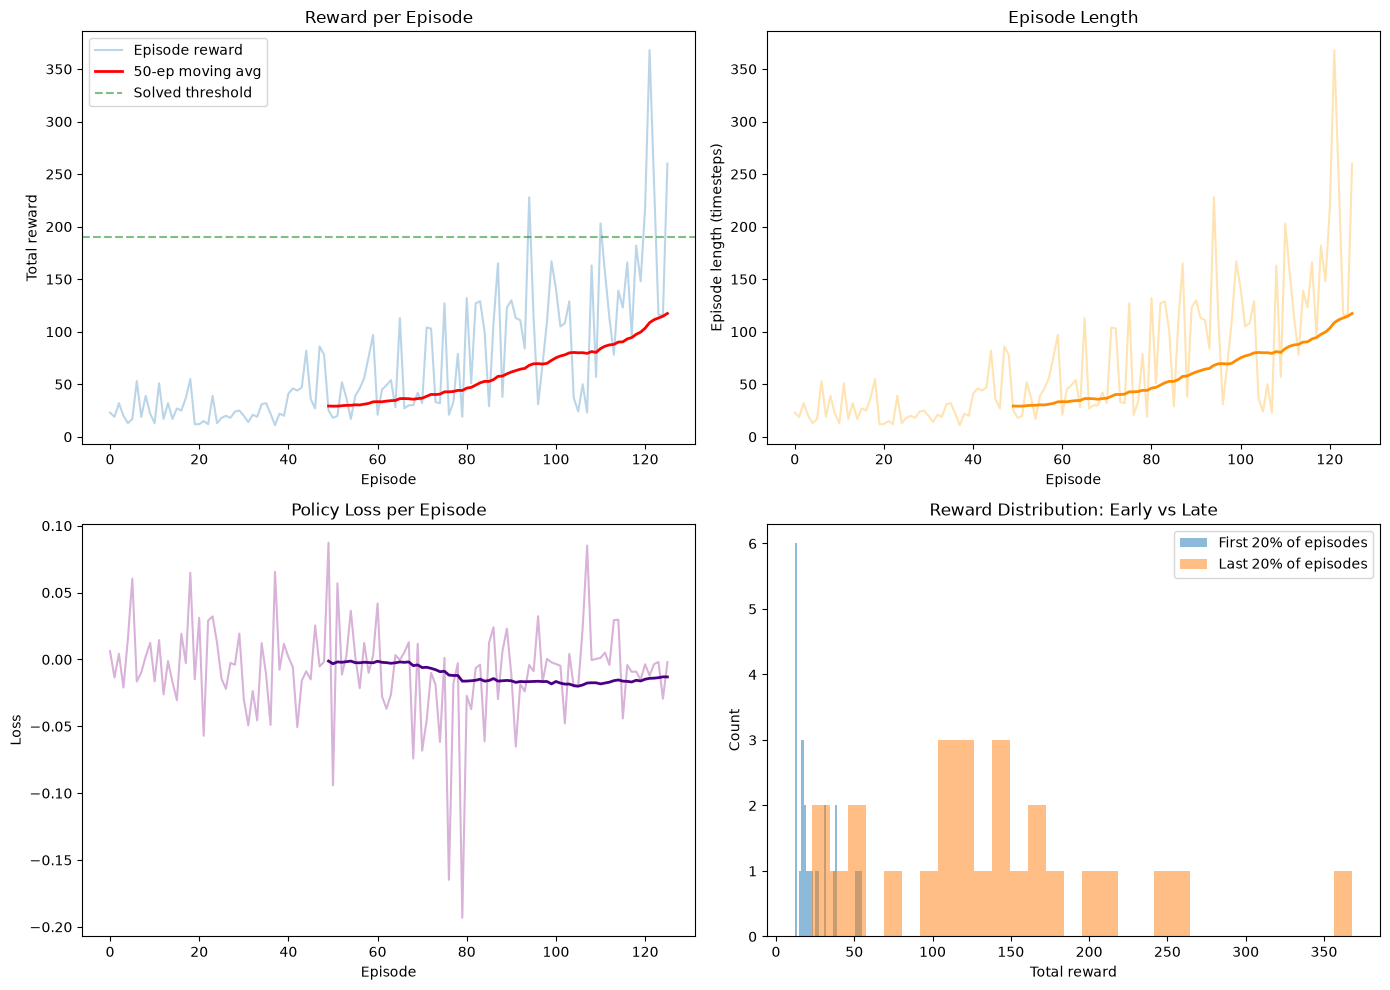

In [12]:
import matplotlib.pyplot as plt
import numpy as np

episodes_arr = np.array([r[0] for r in stats_rewards_list])
rewards_arr  = np.array([r[1] for r in stats_rewards_list])
lengths_arr  = np.array([r[2] for r in stats_rewards_list])
losses_arr   = np.array(stats_loss_list)

def moving_average(x, window=50):
    if len(x) < window:
        return x, np.arange(len(x))
    ma = np.convolve(x, np.ones(window)/window, mode='valid')
    return ma, np.arange(window - 1, len(x))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Reward per episode + moving average
ax = axes[0, 0]
ax.plot(episodes_arr, rewards_arr, alpha=0.3, label='Episode reward')
ma, ma_idx = moving_average(rewards_arr, window=50)
ax.plot(episodes_arr[ma_idx], ma, color='red', linewidth=2, label='50-ep moving avg')
ax.axhline(190, color='green', linestyle='--', alpha=0.5, label='Solved threshold')
ax.set_xlabel('Episode')
ax.set_ylabel('Total reward')
ax.set_title('Reward per Episode')
ax.legend()

# 2. Episode length
ax = axes[0, 1]
ax.plot(episodes_arr, lengths_arr, alpha=0.3, color='orange')
ma_len, ma_len_idx = moving_average(lengths_arr, window=50)
ax.plot(episodes_arr[ma_len_idx], ma_len, color='darkorange', linewidth=2)
ax.set_xlabel('Episode')
ax.set_ylabel('Episode length (timesteps)')
ax.set_title('Episode Length')

# 3. Loss per episode
ax = axes[1, 0]
ax.plot(episodes_arr[:len(losses_arr)], losses_arr, alpha=0.3, color='purple')
ma_loss, ma_loss_idx = moving_average(losses_arr, window=50)
ax.plot(episodes_arr[:len(losses_arr)][ma_loss_idx], ma_loss, color='indigo', linewidth=2)
ax.set_xlabel('Episode')
ax.set_ylabel('Loss')
ax.set_title('Policy Loss per Episode')

# 4. Reward distribution: early vs late training
ax = axes[1, 1]
n = len(rewards_arr)
early = rewards_arr[:n // 5] if n >= 5 else rewards_arr
late = rewards_arr[-n // 5:] if n >= 5 else rewards_arr
ax.hist(early, bins=30, alpha=0.5, label='First 20% of episodes')
ax.hist(late, bins=30, alpha=0.5, label='Last 20% of episodes')
ax.set_xlabel('Total reward')
ax.set_ylabel('Count')
ax.set_title('Reward Distribution: Early vs Late')
ax.legend()

plt.tight_layout()
plt.show()

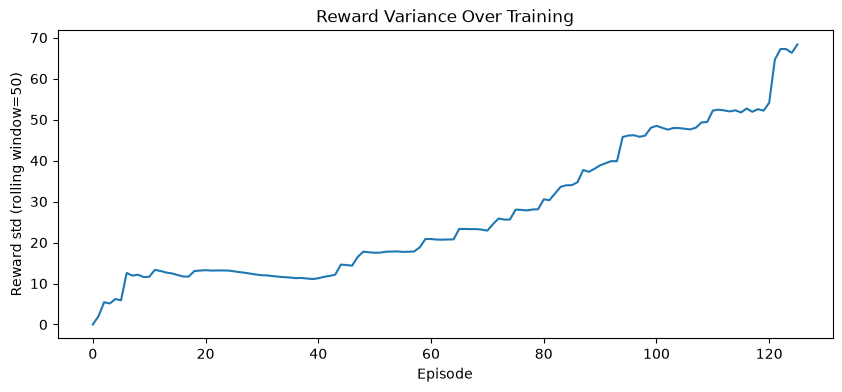

In [13]:
# rolling reward variance

window = 50
rolling_std = np.array([np.std(rewards_arr[max(0,i-window):i+1]) for i in range(len(rewards_arr))])
plt.figure(figsize=(10, 4))
plt.plot(episodes_arr, rolling_std)
plt.xlabel('Episode')
plt.ylabel('Reward std (rolling window=50)')
plt.title('Reward Variance Over Training')
plt.show()